In [1]:
model_ckpt = "meta-llama/Llama-3.2-1B"

In [59]:
import itertools
import random
import transformers
import plotly.express
import plotly.graph_objects
import torch
import sklearn.decomposition
import PIL.Image
import matplotlib
import numpy as np
from torch import Tensor

def pca(embs: Tensor, low_dim: int) -> Tensor:
    pca = sklearn.decomposition.PCA(n_components=low_dim)
    reduced_embs = pca.fit_transform(embs.detach().numpy())
    return torch.tensor(reduced_embs)

def fourier(embs: Tensor) -> Tensor:
    return torch.fft.fft(embs, dim=0)

def vis_emb(embs: Tensor, colorful: bool) -> PIL.Image.Image:
    x = embs.cpu().detach()
    x_normalized = (x - x.min()) / (x.max() - x.min())
    theme = matplotlib.colormaps["Blues"]
    if colorful:
        x_normalized = theme(x_normalized)
    else:
        x_normalized = x_normalized.numpy()
    vis = PIL.Image.fromarray((x_normalized * 255).astype(np.uint8))
    return vis

model = transformers.AutoModelForCausalLM.from_pretrained(model_ckpt).eval()
tokenizer = transformers.AutoTokenizer.from_pretrained(model_ckpt)


In [ ]:
all_pairs_mult = [(x1, x2) for x1, x2 in itertools.product(range(0, 1000), repeat=2) if 0 <= x1 * x2 <= 999]
all_pairs_add = [(x1, x2) for x1, x2 in itertools.product(range(0, 1000), repeat=2) if 0 <= x1 + x2 <= 999]

# select a random pair for every possible output
rng = random.Random(0)
input_pairs_mult = []
for result in range(0, 1000):
    possible_pairs = [pair for pair in all_pairs_mult if pair[0] * pair[1] == result]
    selected_pair = rng.choice(possible_pairs)
    input_pairs_mult.append(selected_pair)

rng = random.Random(0)
input_pairs_add = []
for result in range(0, 1000):
    possible_pairs = [pair for pair in all_pairs_add if pair[0] + pair[1] == result]
    selected_pair = rng.choice(possible_pairs)
    input_pairs_add.append(selected_pair)


In [97]:
inputs_str_mult = [f"{x1} multiplied by {x2} is " for x1, x2 in input_pairs_mult]
inputs_mult = tokenizer(inputs_str_mult, return_tensors="pt")

inputs_str_add = [f"{x1} plus {x2} is " for x1, x2 in input_pairs_add]
inputs_add = tokenizer(inputs_str_add, return_tensors="pt")

with torch.no_grad():
    outputs_mult = model(**inputs_mult, output_hidden_states=True)
    outputs_add = model(**inputs_add, output_hidden_states=True)

preds_mult = torch.tensor(list(map(int, tokenizer.batch_decode(outputs_mult.logits[:, -1, :].argmax(dim=-1).reshape(-1, 1), skip_special_tokens=True))))
acc_mult = (preds_mult == torch.tensor([x1 * x2 for x1, x2 in input_pairs_mult])).float().mean().item()

preds_add = torch.tensor(list(map(int, tokenizer.batch_decode(outputs_add.logits[:, -1, :].argmax(dim=-1).reshape(-1, 1), skip_special_tokens=True))))
acc_add = (preds_add == torch.tensor([x1 + x2 for x1, x2 in input_pairs_add])).float().mean().item()

f"{acc_mult=} {acc_add=}"

'acc_mult=0.8259999752044678 acc_add=0.8740000128746033'

In [101]:
resolution = (800, 200)

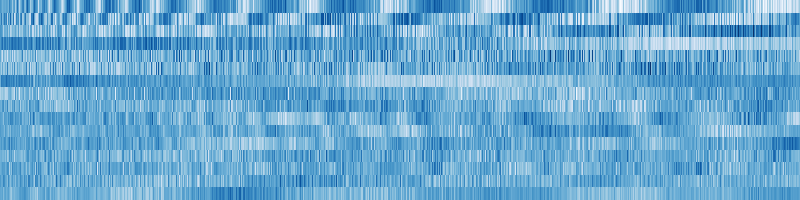

In [104]:
vis_emb(
    pca(outputs_mult.hidden_states[-1][:, -1, :], 16).T,
    colorful=True,
).resize((resolution), PIL.Image.Resampling.NEAREST)

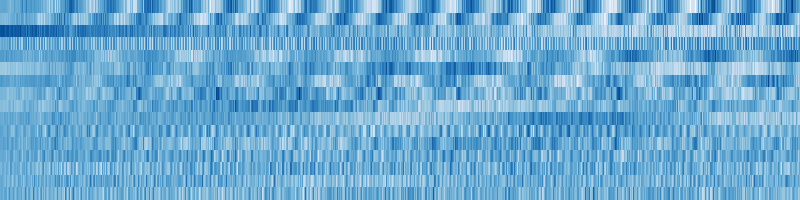

In [105]:
vis_emb(
    pca(outputs_add.hidden_states[-1][:, -1, :], 16).T,
    colorful=True,
).resize((resolution), PIL.Image.Resampling.NEAREST)

In [92]:
inputs_str_mult = [f"{x1} * {x2} = " for x1, x2 in input_pairs_mult]
inputs_mult = tokenizer(inputs_str_mult, return_tensors="pt")

inputs_str_add = [f"{x1} + {x2} = " for x1, x2 in input_pairs_add]
inputs_add = tokenizer(inputs_str_add, return_tensors="pt")

with torch.no_grad():
    outputs_mult = model(**inputs_mult, output_hidden_states=True)
    outputs_add = model(**inputs_add, output_hidden_states=True)

preds_mult = torch.tensor(list(map(int, tokenizer.batch_decode(outputs_mult.logits[:, -1, :].argmax(dim=-1).reshape(-1, 1), skip_special_tokens=True))))
acc_mult = (preds_mult == torch.tensor([x1 * x2 for x1, x2 in input_pairs_mult])).float().mean().item()

preds_add = torch.tensor(list(map(int, tokenizer.batch_decode(outputs_add.logits[:, -1, :].argmax(dim=-1).reshape(-1, 1), skip_special_tokens=True))))
acc_add = (preds_add == torch.tensor([x1 + x2 for x1, x2 in input_pairs_add])).float().mean().item()

f"{acc_mult=}, {acc_add=}"

'acc_mult=0.2809999883174896, acc_add=0.9449999928474426'

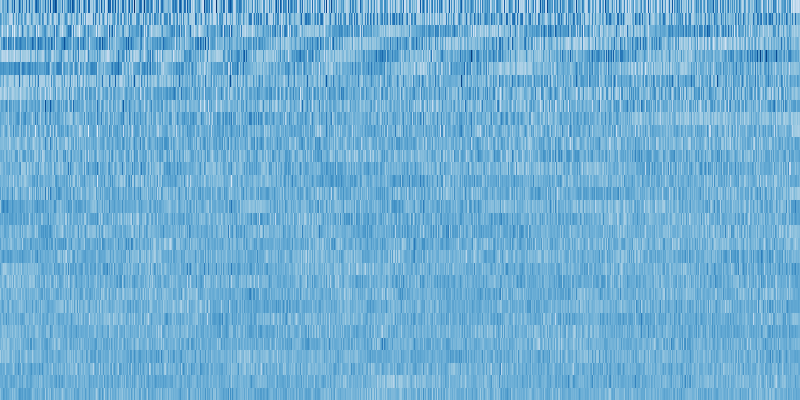

In [93]:
vis_emb(
    pca(outputs_mult.hidden_states[-1][:, -1, :], 32).T,
    colorful=True,
).resize((resolution), PIL.Image.Resampling.NEAREST)

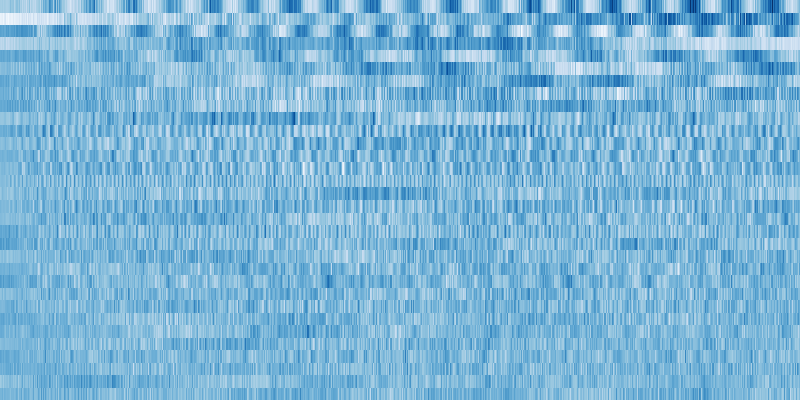

In [94]:
vis_emb(
    pca(outputs_add.hidden_states[-1][:, -1, :], 32).T,
    colorful=True,
).resize((resolution), PIL.Image.Resampling.NEAREST)